In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
# Load data
df = pd.read_csv("final_dataset_clean.csv")
df

,FAS,FADD,TNFRSF10B,CASP8,CASP10,BAX,BAK1,BCL2,BCL2L1,BID,...,ATM,ATR,CDKN1A,AKT1,PIK3CA,MAPK1,MAPK3,NFKB1,RELA,Label
0,17.6489,8.5690,38.7923,37.3829,46.7104,47.1655,104.6118,2.3148,129.7984,9.6899,...,9.3920,5.4505,90.3495,65.1886,6.2874,71.4710,99.6638,51.9557,68.8750,1
1,7.3445,2.4974,41.7550,30.1703,34.6277,79.9012,49.0536,5.2001,136.0001,38.2409,...,8.0372,4.0332,83.5575,45.4924,10.6605,114.4815,74.9641,51.3441,78.4810,1
2,42.6877,7.2301,46.4617,29.5610,16.1240,100.3864,70.9382,1.6344,146.6188,11.1545,...,7.7234,6.6652,79.9415,38.8758,7.1275,71.6468,105.6164,57.7479,131.6712,1
3,30.1779,3.3804,67.0687,11.4856,14.4276,39.4498,34.7411,5.2743,239.2128,18.4350,...,5.0793,1.9976,1041.5522,42.6198,7.5269,105.3382,79.8571,84.5937,126.2031,0
4,12.1105,6.8079,31.8712,19.0066,24.1667,69.5610,70.4022,2.6067,97.5120,34.9981,...,6.6949,2.8540,263.5924,52.9795,6.9217,91.7728,60.2527,36.6910,74.3227,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,4.3853,6.0532,38.5283,15.2307,10.9876,70.3911,23.5385,3.9974,76.8601,12.6360,...,9.1562,5.9273,64.1258,36.7158,6.3682,105.2403,94.7913,25.0667,39.1667,1
153,14.3487,2.7352,11.8057,11.3424,8.8833,33.4256,27.4961,1.9430,67.3755,21.2789,...,2.8756,1.2914,50.3402,22.0012,3.8461,68.7885,56.6744,18.8797,26.5781,0
154,13.6959,5.0749,54.9539,23.1437,19.4375,105.0042,40.8466,3.7742,174.9889,49.3429,...,9.5732,5.2489,291.8196,65.0536,7.8248,101.2285,68.2520,34.3318,66.3796,1
155,8.3946,7.0723,44.6319,10.5967,9.6230,63.0879,51.8170,3.7881,121.6894,31.8276,...,4.7342,4.5351,93.3671,38.5334,6.3050,53.5956,37.3436,39.0269,70.2614,1


In [6]:
X = df.drop("Label", axis=1)
y = df["Label"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [14]:
# Predictions
y_pred = model.predict(X_test_scaled)


In [16]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 0.9375

Report:
               precision    recall  f1-score   support

           0       1.00      0.82      0.90        11
           1       0.91      1.00      0.95        21

    accuracy                           0.94        32
   macro avg       0.96      0.91      0.93        32
weighted avg       0.94      0.94      0.94        32



In [18]:
# Feature Importance
importances = model.feature_importances_
feature_names = X.columns

In [21]:
importance_df = pd.DataFrame({"Gene": feature_names, "Importance": importances}).sort_values(by="Importance", ascending=False)

In [24]:
print("\nFeature Importance:\n")
print(importance_df)


Feature Importance:

         Gene  Importance
14      CASP3    0.122621
6        BAK1    0.116344
15      CASP6    0.104269
19       TP53    0.084542
18     DIABLO    0.063892
3       CASP8    0.062982
22        ATR    0.055549
17       XIAP    0.038731
1        FADD    0.034287
27      MAPK3    0.032639
0         FAS    0.032619
23     CDKN1A    0.031736
16      CASP7    0.027053
11       CYCS    0.018210
26      MAPK1    0.016423
9         BID    0.014842
8      BCL2L1    0.013703
29       RELA    0.013572
24       AKT1    0.013002
28      NFKB1    0.012305
7        BCL2    0.011712
2   TNFRSF10B    0.011357
25     PIK3CA    0.011321
4      CASP10    0.010736
21        ATM    0.008881
10        BAD    0.008303
20       MDM2    0.008214
13      CASP9    0.007720
12      APAF1    0.007063
5         BAX    0.005370


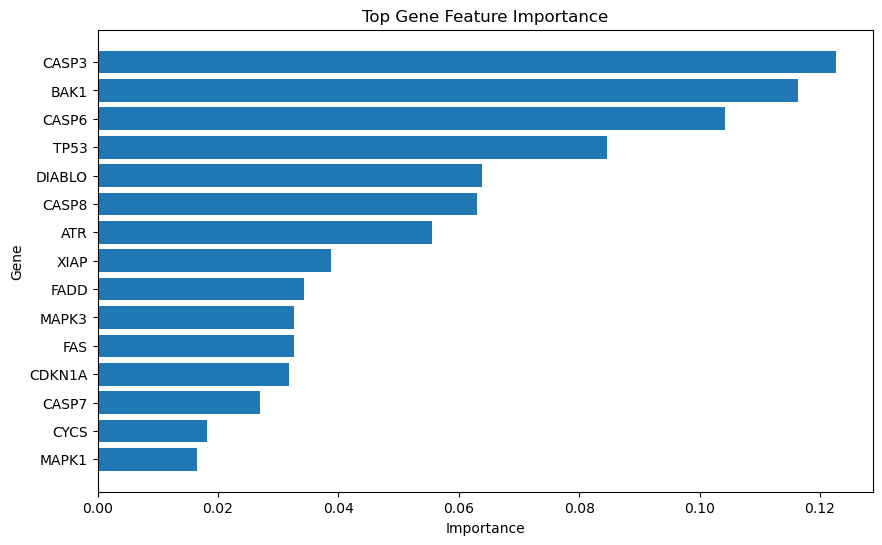

In [26]:
# Assuming importance_df already exists
top_n = 15  # show top 15 genes

top_features = importance_df.head(top_n)

plt.figure(figsize=(10,6))
plt.barh(top_features["Gene"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Gene")
plt.title("Top Gene Feature Importance")
plt.gca().invert_yaxis()  # highest on top
plt.show()